# Standard incomplete markets model

Sara Casella

RoME - Dynamic Macroeconomics

January-February 2026

## The model

There is a measure 1 of households, each facing the problem:

\begin{equation*}
\begin{gathered}
V(a, y)=\max _{c > 0, a^{\prime} \geq 0} u(c)+\beta \int V\left(a^{\prime}, y^{\prime}\right)d\Pi(y^{\prime}|y) \\
\text { s.t. } c+a^{\prime}= y+(1+r) a
\end{gathered}
\end{equation*}


 

with $y$ following an AR(1) log-normal process:
$$\log y_{t} = \rho \log y_{t-1} + \epsilon_{t}, \quad \epsilon_t \sim \mathcal{N} \left(0,\sigma_{\epsilon}^2\right)$$


## Solving the model


1. Discretize state space: get grid for $a$ and $y$ and Markov Chain for $y$


2. Solve for policy functions: get policies $a'(a,y)$ and $c(a,y)$ on the grids. 


3. Solve for steady-state distribution: get discretized agents distribution $D(a,y)$


4. Find aggregate assets and consumption: combine steps 2 and 3 to get aggregates



### Preliminaries: import libraries

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

## 1. Discretize state space

### Discretize assets

We can use a uniform grid, or a double-exponential grid. The code for both options is below. For the double-exponential grid on $[\underline{a}, \overline{a}]$:

- Start with uniformly spaced points $u_i$ on an interval $[\underline{a},\bar{u}]$, construct gridpoints $a_i$

$$
a_i = \underline{a} + e^{e^{u_i}-1}-1 
$$

- This gives min of $\underline{a}$, max of $e^{e^{\bar{u}}-1}-1$. Equating this max with $\overline{a}$ gives

$$
\bar{u} = \log(1+\log(1+ \overline{a} - \underline{a}))
$$



In [4]:
def discretize_assets_uniform(amax, n_a, amin=0):
    """Create uniform grid between amin and amax
    
    Input(s)
    ----------
    amax: integer, grid upper bound
    n_a : integer, number of points in grid
    amin:  [optional] integer, grid lower bound

    Output(s)
    ----------
    a_grid : array (n_a), uniform grid
    """

    a_grid = np.linspace(amin, amax, n_a) 
    a_grid[0] = amin  # make sure *exactly* equal to amin
    return a_grid


def discretize_assets_exponential(amax, n_a, amin=0):
    """Create grid between amin and amax, with more points towards amin
    
        
    Input(s)
    ----------
    amax: integer, grid upper bound
    n_a : integer, number of points in grid
    amin: [optional] integer, grid lower bound

    Output(s)
    ----------
    a_grid : array (n_a), double exponential grid
    """

    # find maximum ubar of uniform grid corresponding to desired maximum amax of asset grid
    ubar = np.log(1 + np.log(1 + amax - amin))
    
    # make uniform grid
    u_grid = np.linspace(0, ubar, n_a)
    
    # double-exponentiate uniform grid and add amin to get grid from amin to amax
    return amin + np.exp(np.exp(u_grid) - 1) - 1

Let's create two grids with 50 points between 0 and 100 and visualize results.

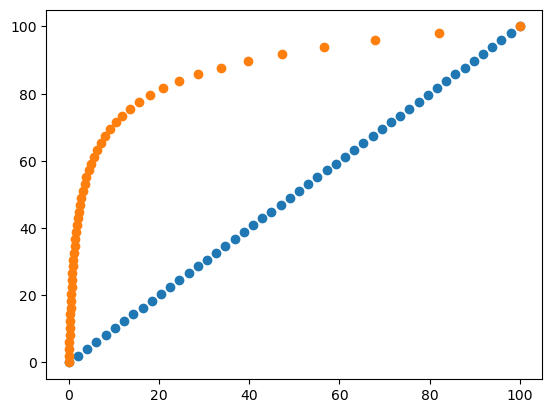

In [3]:
a_grid_uniform = discretize_assets_uniform(100, 50)
a_grid_exponential = discretize_assets_exponential(100, 50)

plt.scatter(a_grid_uniform,a_grid_uniform)
plt.scatter(a_grid_exponential,a_grid_uniform)
plt.show()

### Discretize income process

We'll use **Rouwenhorst** method for discretization ([see Kopecky and Suen](http://www.karenkopecky.net/Rouwenhorst_WP.pdf)).


In [15]:
def stationary_markov(Pi, tol=1E-11):
    """Find invariant distribution of a Markov chain by iteration.
        
    Input(s)
    ----------
    Pi: array(n x n), Markov chain
    tol:  [optional] integer, tolerance

    Output(s)
    ----------
    pi : array(n), stationary distribution of Pi
    """

    # start with uniform distribution over all states
    n = Pi.shape[0]
    pi = np.full(n, 1/n)
    
    # update distribution using Pi until successive iterations differ by less than tol
    for _ in range(10_000):
        pi_new = Pi.T @ pi
        if np.max(np.abs(pi_new - pi)) < tol:
            return pi_new
        pi = pi_new


def rouwenhorst(rho, sigma, n_y=7):
    """Rouwenhorst method
    
    Input(s)
    ----------
    rho:    float, persistence income process
    sigma:  float, variance income process
    n_y  :  [optional] integer, number of points income grid

    Output(s)
    ----------
    y_grid: array (n_y), income grid
    pi:     array(n_y), stationary distribution of Pi
    Pi:     array(n_y x n_y), associated Markov chain
    """
    
    # choose inner-switching probability p to match persistence rho
    p = (1 + rho) / 2
    
    # parametrize Rouwenhorst for n=2
    Pi = np.array([[p, 1 - p], [1 - p, p]])

    # implement recursion to build from n=3 to n=N
    for n in range(3, n_y + 1):
        P1, P2, P3, P4 = (np.zeros((n, n)) for _ in range(4))
        P1[:-1, :-1] = p * Pi
        P2[:-1, 1:] = (1 - p) * Pi
        P3[1:, :-1] = (1 - p) * Pi
        P4[1:, 1:] = p * Pi
        Pi = P1 + P2 + P3 + P4
        Pi[1:-1] /= 2

    # invariant distribution 
    pi = stationary_markov(Pi)
    
    # create income grid and scaling so income has mean 1
    s = np.linspace(-1, 1, n_y)
    s *= (sigma / np.sqrt(np.sum(pi * (s - np.sum(pi * s)) ** 2))) # variance
    y_grid = np.exp(s) / np.sum(pi * np.exp(s))

    return y_grid, pi, Pi

### Examples

In [16]:
y_grid, pi, Pi = rouwenhorst(0.98, 0.07, n_y=7)


In [17]:
print('Income grid: ', y_grid)

Income grid:  [0.84036921 0.88979944 0.94213714 0.99755333 1.05622908 1.11835612
 1.18413745]


In [18]:
print('Markov chain: \n', np.round(Pi,2))

Markov chain: 
 [[0.94 0.06 0.   0.   0.   0.   0.  ]
 [0.01 0.94 0.05 0.   0.   0.   0.  ]
 [0.   0.02 0.94 0.04 0.   0.   0.  ]
 [0.   0.   0.03 0.94 0.03 0.   0.  ]
 [0.   0.   0.   0.04 0.94 0.02 0.  ]
 [0.   0.   0.   0.   0.05 0.94 0.01]
 [0.   0.   0.   0.   0.   0.06 0.94]]


In [19]:
print('Stationary distribution: \n', np.round(pi,2))

Stationary distribution: 
 [0.02 0.09 0.23 0.31 0.23 0.09 0.02]


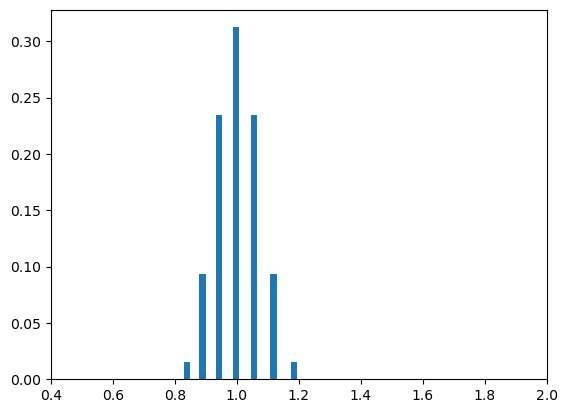

In [20]:
plt.bar(y_grid,pi,width=0.02)
plt.xlim(0.4, 2)
plt.show()

In [21]:
print('Mean income: ', y_grid@pi)
mean_log_y = np.vdot(pi, np.log(y_grid))
sd_log_y = np.sqrt(np.vdot(pi, (np.log(y_grid) - mean_log_y)**2))
print('Standard deviation: ', sd_log_y)

Mean income:  1.0
Standard deviation:  0.07000000000000002


Mean income:  1.0
Standard deviation:  0.3


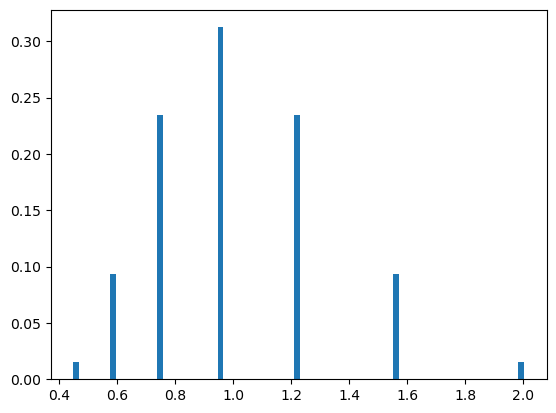

In [22]:
y_grid, pi, Pi = rouwenhorst(0.98, 0.3, n_y=7)

print('Mean income: ', y_grid@pi)
mean_log_y = np.vdot(pi, np.log(y_grid))
sd_log_y = np.sqrt(np.vdot(pi, (np.log(y_grid) - mean_log_y)**2))
print('Standard deviation: ', sd_log_y)

plt.bar(y_grid,pi,width=0.02)
plt.show()

## 2. Obtain Value and Policy Functions

We will solve the individual household problem with two methods:

- Standard value function iteration, using the monotonicity of choices

- Value function iteration with endogenous grid method

***Standard VFI function, using monotonicity of choices***

In [23]:
def utility_function(c, eis):
    
    """Returns u(c) given parameters
    
    Input(s)
    ----------
    c: can be float or array, consumption
    eis: float, elasticity of intertemporal substitution

    Output(s)
    ----------
    u: u(c)

    """
    if eis == 1:
        u = np.log(c)
    else:
        u = c ** (1-1/eis)/(1-1/eis)
    return u


def vfi_monotonicity(gridAssets, gridIncome, Pi, r, beta, eis, tol=1E-9, maxit = 10_000):
    

    '''Value function iteration using monotonicity of choices
    
    Input(s)
    ----------
    gridAssets: array(n_a), assets grid
    gridIncome: array(n_y), income grid
    Pi:        array(n_y x n_y), income Markov chain
    r:      float, interest rate
    beta:   float, discount factor
    eis:    float, elasticity of intertemporal substitution
    
    tol:      [optional] float, tolerance
    maxit:    [optional] integer, maximum number of iterations

    Output(s)
    ----------
    valueFunctionNew:   array(n_y x n_a), value function
    assetPolicy:        array(n_y x n_a), asset policy function
    consumptionPolicy:  array(n_y x n_a), consumption policy function
    
    '''
       
    nGridAssets      = len(gridAssets)
    nGridIncome      = len(gridIncome)
    
    
    # initial guess for V: zeros
    valueFunction = np.zeros((nGridIncome,nGridAssets),dtype=float)
 
    # Placeholder for new value function and policy functions
    valueFunctionNew    = np.zeros_like(valueFunction)
    assetPolicy         = np.zeros_like(valueFunction)
    consumptionPolicy   = np.zeros_like(valueFunction)

    maxDifference = 10.0
    it = 0
    
    # iterate until maximum distance between two iterations falls below tol, fail-safe max of 10,000 iterations
    while(it < maxit and maxDifference > tol):
        
        expectedValueFunction = Pi @ valueFunction 
        
        # For each level of income
        for iIncome in range(nGridIncome):

            # We start from first possible choice
            gridAssetsNextPeriod = 0

            # For each level of assets
            for iAsset in range(nGridAssets):

                valueHighSoFar = -100000.0
                assetChoice  = gridAssets[0]

                # We choose the next level of assets (a') that maximizes utility
                # We start from previous choice (monotonicity of policy function)
                for iAssetNextPeriod in range(gridAssetsNextPeriod,nGridAssets):

                    consumption = gridIncome[iIncome] + (1+r)*gridAssets[iAsset] - gridAssets[iAssetNextPeriod]

                    periodUtility = utility_function(consumption, eis)
                    valueProvisional = (1-beta)*periodUtility+ beta*expectedValueFunction[iIncome,iAssetNextPeriod];

                    if  valueProvisional>valueHighSoFar:
                        valueHighSoFar = valueProvisional
                        assetChoice = gridAssets[iAssetNextPeriod]
                        gridAssetsNextPeriod = iAssetNextPeriod
                    else:
                        break # We break when we have achieved the max


                valueFunctionNew[iIncome,iAsset] = valueHighSoFar
                assetPolicy[iIncome,iAsset]      = assetChoice
                consumptionPolicy[iIncome,iAsset] = consumption

        # Compare new value function to old one
        maxDifference = np.max(np.abs(valueFunctionNew - valueFunction))
            
        if(it%10 == 0 or it == 0):
            print(" Iteration = ", it, ", Sup Diff = ", maxDifference )
        it += 1
        
        valueFunction    = valueFunctionNew
        valueFunctionNew = np.zeros_like(valueFunction)

    return valueFunction, assetPolicy, consumptionPolicy



***EGM***

In [24]:
def vfi_egm(a_grid, y_grid, Pi, r, beta, eis, tol=1E-9, maxit=10_000):
        
    '''Value function iteration using endogenous grid method
    
    Input(s)
    ----------
    a_grid: array(n_a), assets grid
    y_grid: array(n_y), income grid
    Pi:     array(n_y x n_y), income Markov chain
    r:      float, interest rate
    beta:   float, discount factor
    eis:    float, elasticity of intertemporal substitution
   
    tol:   [optional] float, tolerance
    maxit: [optional] integer, maximum number of iterations

    Output(s)
    ----------
    Va:   array(n_y x n_a), derivative of value function
    a:    array(n_y x n_a), asset policy function
    c:    array(n_y x n_a), consumption policy function
    
    '''

    # initial guess for Va: assume consumption 5% of cash-on-hand, then get Va from envelope condition
    coh = y_grid[:, np.newaxis] + (1+r)*a_grid
    c = 0.05 * coh
    Va = (1+r) * c ** (-1/eis)
    
    a_old = np.zeros_like(c)
    
    # iterate until maximum distance between two iterations falls below tol, fail-safe max of 10,000 iterations
    for it in range(maxit):
        
        
        # step 1: discounting and expectations
        uc_endog = beta * Pi @ Va
        
        # # step 2: calculate unconstrained endogenous c and m
        c_endog = uc_endog ** (-eis) # endogenous consumption c(a_t+1,y_t)
        m_endog = y_grid[:, np.newaxis] + (1+r)*a_grid #endogenous resources m(a_t+1,y_t)
        
        # step 3: interpolate to get asset policy function
        a = np.empty_like(c_endog)
        for y in range(len(y_grid)):
            a[y, :] = np.interp(m_endog[y, :], c_endog[y, :] + a_grid, a_grid)  # a'(a_t,y_t)
            
        # m_endog = c_endog[y, :] - y_grid[:, np.newaxis] + a_grid #endogenous resources m(a_t+1,y_t)
        
        # # step 3: interpolate to get asset policy function
        # a = np.empty_like(c_endog)
        # for y in range(len(y_grid)):
        #     a[y, :] = np.interp((1+r)*a_grid, m_endog[y, :], a_grid)  # a'(a_t,y_t)
        

        # step 4: enforcing the borrowing constraint and backing out consumption
        a = np.maximum(a, a_grid[0])
        c = m_endog - a # c(a_t,y_t)
        
        # step 5: using the envelope condition to recover the new derivative of the value function
        Va = (1+r) * c ** (-1/eis)
        
        # after iteration 0, can compare new policy function to old one
        if it > 0 and np.max(np.abs(a - a_old)) < tol:
            break    
        
        a_old = a
        
    return Va, a, c

#### Solving the household problem

In [25]:
# Model Parameters
beta = 0.96         # discount factor
eis = 1             # elasticity of intertemporal substitution
r =  0.04           # interest rate
amin  = 0           # borrowing constraint
rho   = 0.98        # persistence income process
sigma = 0.7         # variance income process

# Computational parameters
amax = 320
nA = 400
nY = 7

# Grids
a_grid = discretize_assets_exponential(amax, nA, amin)
y_grid, pi, Pi = rouwenhorst(rho, sigma, nY)

# Value and policy functions using standard discrete vfi
start_time = time.time()
V_m, a_m, c_m = vfi_monotonicity(a_grid, y_grid, Pi, r, beta, eis) #, c_m
print("--- %s seconds ---" % (time.time() - start_time)) 

# Check that upper bound is high enough
print(a_grid[np.argmax(a_m[-2,:]<a_grid)])


 Iteration =  0 , Sup Diff =  0.23282252866313033
 Iteration =  10 , Sup Diff =  0.07450588235607092
 Iteration =  20 , Sup Diff =  0.041989954061792956
 Iteration =  30 , Sup Diff =  0.024485190703474657
 Iteration =  40 , Sup Diff =  0.01570466756359057
 Iteration =  50 , Sup Diff =  0.010164288555396528
 Iteration =  60 , Sup Diff =  0.006622469748001514
 Iteration =  70 , Sup Diff =  0.004336079802630177
 Iteration =  80 , Sup Diff =  0.002849368993261603
 Iteration =  90 , Sup Diff =  0.0018774469638329627
 Iteration =  100 , Sup Diff =  0.0012395381441132614
 Iteration =  110 , Sup Diff =  0.000819617923301319
 Iteration =  120 , Sup Diff =  0.0005425823558806719
 Iteration =  130 , Sup Diff =  0.0003595064585635299
 Iteration =  140 , Sup Diff =  0.00023836799961696187
 Iteration =  150 , Sup Diff =  0.00015813355640581506
 Iteration =  160 , Sup Diff =  0.00010495063356863454
 Iteration =  170 , Sup Diff =  6.967750746644796e-05
 Iteration =  180 , Sup Diff =  4.627184493566361

In [26]:
# Value and policy functions using endogenous grid method

start_time = time.time()
Va, a, c = vfi_egm( a_grid, y_grid, Pi, r, beta, eis)
print("--- %s seconds ---" % (time.time() - start_time)) 

--- 0.015264034271240234 seconds ---


### Some plots

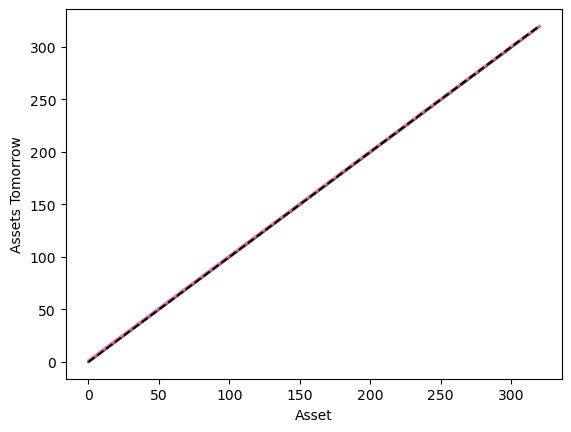

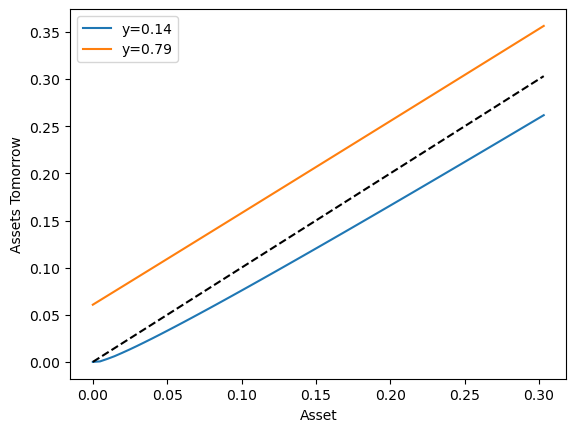

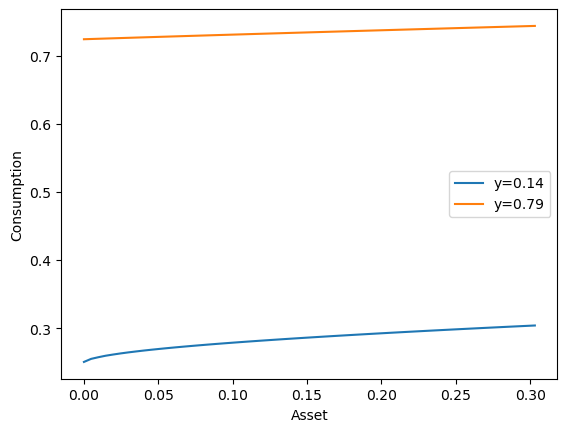

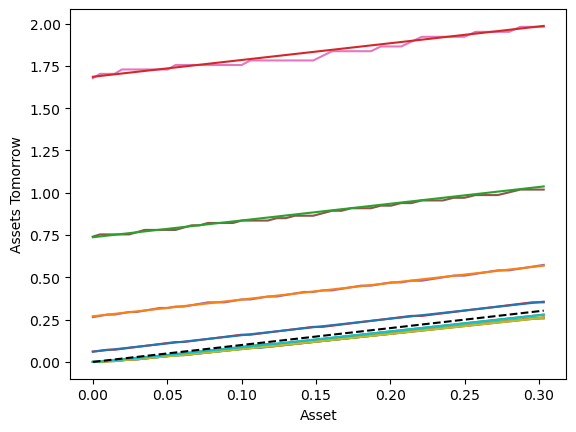

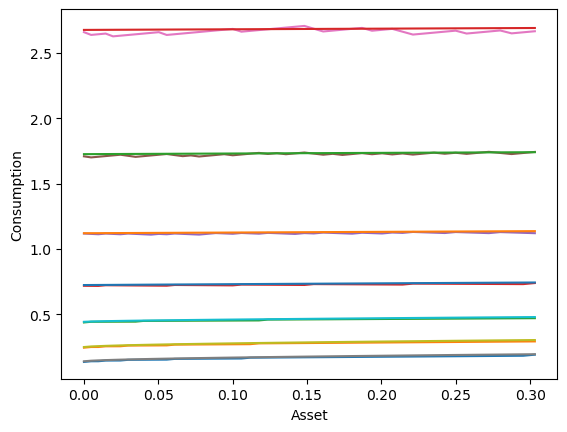

In [27]:
# Plot equilibrium policies
plt.plot(a_grid, a.T)
plt.plot(a_grid, a_grid, 'k--')
plt.xlabel('Asset'), plt.ylabel('Assets Tomorrow')
plt.show()

plt.plot(a_grid[0:50], a[1,0:50].T)
plt.plot(a_grid[0:50], a[3,0:50].T)
plt.plot(a_grid[0:50], a_grid[0:50], 'k--')
plt.legend([f'y={y_grid[0]:.2f}', f'y={y_grid[3]:.2f}'])
plt.xlabel('Asset'), plt.ylabel('Assets Tomorrow')
plt.show()

plt.plot(a_grid[0:50], c[1,0:50].T)
plt.plot(a_grid[0:50], c[3,0:50].T)
plt.legend([f'y={y_grid[0]:.2f}', f'y={y_grid[3]:.2f}'])
plt.xlabel('Asset'), plt.ylabel('Consumption')
plt.show()

plt.plot(a_grid[0:50], a_m[:,0:50].T)
plt.plot(a_grid[0:50], a[:,0:50].T)
plt.plot(a_grid[0:50], a_grid[0:50], 'k--')
plt.xlabel('Asset'), plt.ylabel('Assets Tomorrow')
plt.show()

plt.plot(a_grid[0:50], c_m[:,0:50].T)
plt.plot(a_grid[0:50], c[:,0:50].T)
plt.xlabel('Asset'), plt.ylabel('Consumption')
plt.show()

## 3. Calculate stationary distribution

We will obtain a discretized distribution giving the mass of agents at each point on our grid.



Let's look at the asset policy function, which we will use to generate the wealth distribution.

Remember $a^{\prime}$ is not always necessarily on the grid $a$ (for the policy function obtained with the endogenous grid method, but not for the one obtained with brute force maximization. Why?)

For example, let's look at asset policy for second-highest income state ($y = y_5$) and assets of zero.

In [28]:
a[5,0]

np.float64(0.7370739472067169)

In [31]:
#np.where(a_grid > a[5,0])

# it is in between points 91 and 92 on the grid
#print(a_grid[91:93])

np.searchsorted(a_grid, a[5,0])

np.int64(92)

We will use the lottery method to assign mass to these two points

In [32]:
def get_lottery(a, a_grid):
    
    # step 1: find the i such that a' lies between gridpoints a_i and a_(i+1)
    a_i = np.searchsorted(a_grid, a) - 1
    
    # step 2: obtain lottery probabilities pi
    a_pi = (a_grid[a_i+1] - a)/(a_grid[a_i+1] - a_grid[a_i])
    
    return a_i, a_pi

Let's try the function out for point a[5,0]

In [33]:
get_lottery(a[5,0], a_grid)

(np.int64(91), np.float64(0.28330680005708514))

Since 0.737 is closer to point 92, point 91 has a lower weight. 

### Steady-state distribution

Now that we can calculate a_i and a_pi for each point on the asset policy function, we can calculate the steady state distribution. We will do so recursively.

In [39]:
@njit
def forward_step(D, Pi_T, x_i, x_pi):
    """Single forward step to update distribution using exogenous Markov transition Pi and
    policy x_i and x_pi for one-dimensional endogenous state.

    Note that it takes Pi_T, the transpose of Pi, as input rather than transposing itself;
    this is so that when it is applied repeatedly, we can precalculate a transpose stored in
    correct order rather than a view.

    Input(s)
    ----------
    D : array (S*X), beginning-of-period distribution over s_t, x_(t-1)
    Pi_T : array (S*S), transpose Markov matrix that maps s_t to s_(t+1)
    x_i : int array (S*X), left gridpoint of endogenous policy
    x_pi : array (S*X), weight on left gridpoint of endogenous policy

    Output(s)
    ----------
    Dnew : array (S*X), beginning-of-next-period dist s_(t+1), x_t
    """

    # first update using endogenous policy
    nZ, nX = D.shape
    Dnew = np.zeros_like(D)
    for iz in range(nZ):
        for ix in range(nX):
            
            i = x_i[iz, ix]
            pi = x_pi[iz, ix]
            d = D[iz, ix]
            
            # send pi of the mass to gridpoint i
            Dnew[iz, i] += d * pi
            
            # send 1-pi of the mass to gridpoint i+1
            Dnew[iz, i+1] += d * (1 - pi)

    # then using exogenous transition matrix
    return Pi_T @ Dnew



def distribution_ss(Pi, a, a_grid, tol=1E-10, maxit=100_000):
    
    """Find steady-state distribution through forward iteration until convergence.

    Inputs
    ----------
    Pi : array
        steady-state Markov matrix for exogenous variable
    a : array
        asset policy
    a_grid : array
        asset grid
    tol : [optional] float
        absolute tolerance for max diff between consecutive iterations for distribution
    maxit : [optional] int
        maximum number of iterations, if 'tol' not reached by then, raise error
 
    Returns
    ----------
    D : array
        steady-state distribution
    """
    
    # as initial D, use stationary distribution for y, plus uniform over a
    pi = stationary_markov(Pi)
    D = pi[:, np.newaxis] * np.ones_like(a_grid) / len(a_grid)

    # obtain interpolated policy rule for each dimension of endogenous policy
    # use robust binary search-based method that only requires grids, not policies, to be monotonic
    a_i, a_pi = get_lottery(a, a_grid)

    # Transpose exogenous matrice once
    Pi_T = Pi.T


    for it in range(maxit):
        Dnew = forward_step(D, Pi_T, a_i, a_pi)

        # only check convergence every 10 iterations for efficiency
        if it % 10 == 0 and np.max(np.abs(D - Dnew)) < tol:
            break
        D = Dnew
    else:
        raise ValueError(f'No convergence after {maxit} forward iterations!')

    return D

Let's test this out

In [41]:
start_time = time.time()
D = distribution_ss(Pi, a, a_grid)
print("--- %s seconds ---" % (time.time() - start_time)) 
D.shape

--- 0.02252197265625 seconds ---


(7, 400)

How can me make this faster?

In [ ]:
# Here: new code 

In [38]:
# Let's try again
start_time = time.time()
D = distribution_ss(Pi, a, a_grid)
print("--- %s seconds ---" % (time.time() - start_time)) 

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Untyped global name 'stationary_markov': Cannot determine Numba type of <class 'function'>

File "../../../../../../var/folders/bz/trd8dfx57ks0slpkzwhs_yj80000gn/T/ipykernel_8556/1967822409.py", line 67:
<source missing, REPL/exec in use?>

During: Pass nopython_type_inference

### Visualizing steady-state distribution

We can plot CDF of assets, obtained by summing `D` across $y$ and taking cumulative sum across $a$.


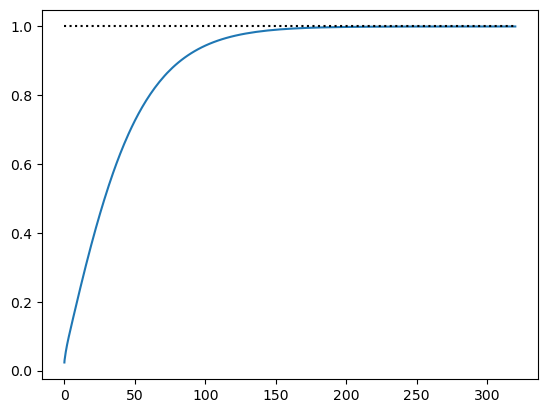

In [42]:
plt.plot(a_grid, D.sum(axis=0).cumsum())
plt.hlines(1,0, a_grid[-1], colors='k', linestyles='dotted');

We can do this for assets < 150

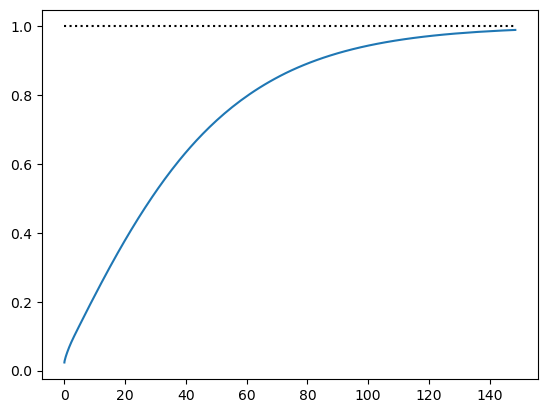

In [43]:
i = np.argmax(a_grid > 150) # first gridpoint above 150
plt.plot(a_grid[:i], D.sum(axis=0)[:i].cumsum())
plt.hlines(1,0, a_grid[i-1], colors='k', linestyles='dotted');

We can also do this separately for each income state

- Plot CDF separately by income state, highly right-skewed in upper states, interesting behavior mostly in $y=0.79$ middle state


- Why? Common occurences with discrete time and discrete states:
    * Mass point at $a=0$ for $y < 0.79$ leads to mass points above 0, as households whose income has increased to $y=0.79$ save for one, two, three, ... periods 
    * Target assets for $y=0.79$ is slightly above 1; $y=0.79$ households converge to this level from both sides but don't cross, more converge from below so density discontinuous

In [ ]:
for iy, y in enumerate(y_grid):
    plt.plot(a_grid[:100], D[iy][:100].cumsum()/pi[iy], label=f'y={y:.2f}')
plt.legend();

### How many assets held in each state?

In [44]:
for iy, y in enumerate(y_grid):
    print(f'Total assets at y={y:.2f} ({100*pi[iy]:.1f}% of hh)\t: {np.vdot(a_grid, D[iy, :]) / pi[iy]:.2f}')



Total assets at y=0.14 (1.6% of hh)	: 22.60
Total assets at y=0.25 (9.4% of hh)	: 25.16
Total assets at y=0.44 (23.4% of hh)	: 29.03
Total assets at y=0.79 (31.2% of hh)	: 35.00
Total assets at y=1.39 (23.4% of hh)	: 44.21
Total assets at y=2.46 (9.4% of hh)	: 58.47
Total assets at y=4.36 (1.6% of hh)	: 80.70


## 4. Aggregate assets and consumption




In [45]:
A = np.vdot(a,D)
C = np.vdot(c,D)

print(A)
print(C)

37.55997691893788
2.5023992161206925


## 5. Putting all together...


In [46]:
def steady_state(Pi, a_grid, y_grid, r, beta, eis):
    
    Va, a, c = vfi_egm(a_grid, y_grid, Pi, r, beta, eis)
    D = distribution_ss(Pi, a, a_grid)
    
    return dict(D=D, Va=Va, 
                a=a, c=c,
                A=np.vdot(a, D), C=np.vdot(c, D), # aggregation
                Pi=Pi, a_grid=a_grid, y_grid=y_grid, r=r, beta=beta, eis=eis)
    

In [47]:
ss = steady_state(Pi, a_grid, y_grid, r, beta, eis)

In [48]:
print(ss.keys())

dict_keys(['D', 'Va', 'a', 'c', 'A', 'C', 'Pi', 'a_grid', 'y_grid', 'r', 'beta', 'eis'])


In [ ]:
print(ss)